In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

# 1. ПАРАМЕТРЫ

n_users = 500
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 1, 30)

base_conversion_rates = {
    'app_open_to_view_card': 0.65,
    'view_card_to_apply': 0.50,
    'apply_to_approved': 0.85,
    'approved_to_first_transfer': 0.45,
    'app_open_to_repeat_visit': 0.35
}

# 2. ГЕНЕРАЦИЯ ПОЛЬЗОВАТЕЛЕЙ

def generate_user_cohort():
    days_range = (end_date - start_date).days
    return start_date + timedelta(days=random.randint(0, days_range - 7))

users = []
for user_id in range(1, n_users + 1):
    user_segment = random.choices(['premium', 'regular', 'new_to_bank'], weights=[0.2, 0.5, 0.3])[0]
    cohort_date = generate_user_cohort()
    user_quality = np.random.normal(0.5, 0.15)
    user_quality = max(0, min(1, user_quality))

    users.append({
        'user_id': user_id,
        'segment': user_segment,
        'cohort_date': cohort_date,
        'user_quality': user_quality
    })

df_users = pd.DataFrame(users)

# 3. ГЕНЕРАЦИЯ СОБЫТИЙ
events_data = []

for _, user in df_users.iterrows():
    user_id = user['user_id']
    cohort = user['cohort_date']
    quality = user['user_quality']
    segment = user['segment']

    first_open = cohort + timedelta(hours=random.randint(1, 48))
    events_data.append({
        'user_id': user_id,
        'event_date': first_open,
        'event_type': 'app_open',
        'segment': segment,
        'days_since_cohort': 0,
        'session_duration_min': random.randint(1, 30)
    })

    prob_view_card = base_conversion_rates['app_open_to_view_card'] * (0.8 + quality * 0.4)
    if random.random() < prob_view_card:
        view_date = first_open + timedelta(hours=random.randint(2, 72))
        events_data.append({
            'user_id': user_id,
            'event_date': view_date,
            'event_type': 'view_card_offer',
            'segment': segment,
            'days_since_cohort': (view_date - cohort).days,
            'session_duration_min': random.randint(2, 20)
        })

        prob_apply = base_conversion_rates['view_card_to_apply'] * (0.7 + quality * 0.6)
        if random.random() < prob_apply:
            apply_date = view_date + timedelta(hours=random.randint(1, 48))
            events_data.append({
                'user_id': user_id,
                'event_date': apply_date,
                'event_type': 'apply_card',
                'segment': segment,
                'days_since_cohort': (apply_date - cohort).days,
                'session_duration_min': random.randint(3, 25)
            })

            prob_approved = base_conversion_rates['apply_to_approved'] * (0.9 + quality * 0.2)
            if random.random() < prob_approved:
                approved_date = apply_date + timedelta(hours=random.randint(6, 72))
                events_data.append({
                    'user_id': user_id,
                    'event_date': approved_date,
                    'event_type': 'card_approved',
                    'segment': segment,
                    'days_since_cohort': (approved_date - cohort).days,
                    'session_duration_min': random.randint(1, 15)
                })

                prob_transfer = base_conversion_rates['approved_to_first_transfer'] * (0.6 + quality * 0.8)
                if random.random() < prob_transfer:
                    transfer_date = approved_date + timedelta(hours=random.randint(2, 120))
                    events_data.append({
                        'user_id': user_id,
                        'event_date': transfer_date,
                        'event_type': 'first_transfer',
                        'segment': segment,
                        'days_since_cohort': (transfer_date - cohort).days,
                        'session_duration_min': random.randint(5, 40)
                    })

    n_repeat_visits = np.random.poisson(quality * 5)
    for i in range(n_repeat_visits):
        days_after = random.randint(3, 25)
        repeat_date = cohort + timedelta(days=days_after)
        if repeat_date <= end_date:
            prob_repeat = base_conversion_rates['app_open_to_repeat_visit'] * (0.5 + quality * 1.0)
            if random.random() < prob_repeat:
                events_data.append({
                    'user_id': user_id,
                    'event_date': repeat_date,
                    'event_type': 'repeat_visit',
                    'segment': segment,
                    'days_since_cohort': days_after,
                    'session_duration_min': random.randint(1, 60)
                })

# Добавляем DAU
for _, user in df_users.iterrows():
    user_id = user['user_id']
    cohort = user['cohort_date']
    quality = user['user_quality']
    segment = user['segment']

    active_days = int(quality * 20) + random.randint(1, 10)
    for day_offset in range(active_days):
        event_day = cohort + timedelta(days=day_offset)
        if event_day <= end_date:
            open_prob = min(1, quality * (0.8 + random.random() * 0.4))
            if random.random() < open_prob:
                events_data.append({
                    'user_id': user_id,
                    'event_date': event_day,
                    'event_type': 'app_open',
                    'segment': segment,
                    'days_since_cohort': day_offset,
                    'session_duration_min': random.randint(1, 45)
                })

df_events = pd.DataFrame(events_data)
df_events = df_events.sort_values(['user_id', 'event_date']).reset_index(drop=True)

# Добавляем полезные колонки
df_events['weekday'] = pd.to_datetime(df_events['event_date']).dt.dayofweek
df_events['weekday_name'] = pd.to_datetime(df_events['event_date']).dt.day_name()
df_events['event_hour'] = pd.to_datetime(df_events['event_date']).dt.hour
df_events['event_date'] = pd.to_datetime(df_events['event_date']).dt.date


# СОХРАНЕНИЕ

df_events.to_excel('bank_app_events.xlsx', index=False, engine='openpyxl')
df_users.to_excel('bank_users.xlsx', index=False, engine='openpyxl')



# ВАРИАНТ 2: CSV с разделителем TAB (для Google Sheets)
# Раскомментируй строки ниже (закомментировав вариант 1):

# df_events.to_csv('bank_app_events.csv', sep='\t', index=False, encoding='utf-8')
# df_users.to_csv('bank_users.csv', sep='\t', index=False, encoding='utf-8')
# print("✅ Сохранено в CSV с разделителем TAB")
# print("   При открытии в Google Sheets выбери: Файл → Импорт → Разделитель: Табуляция")


# ВАРИАНТ 3: CSV с разделителем ; (для Excel на русской Windows)
# Раскомментируй строки ниже:

# df_events.to_csv('bank_app_events_semicolon.csv', sep=';', index=False, encoding='utf-8-sig')
# df_users.to_csv('bank_users_semicolon.csv', sep=';', index=False, encoding='utf-8-sig')
# print("✅ Сохранено в CSV с разделителем ;")
# print("   Должно открыться в Excel автоматически с корректными столбцами")


# Скачивание для Colab
try:
    from google.colab import files

    # Скачиваем в зависимости от выбранного формата
    try:
        files.download('bank_app_events.xlsx')
        files.download('bank_users.xlsx')

    except:
        try:
            files.download('bank_app_events.csv')
            files.download('bank_users.csv')
        except:
            pass

except:
    print("⚠️ Для скачивания файлов используй меню Colab: Файл → Скачать")



# Показываем пример
print("\nПРИМЕР ПЕРВЫЕ 5 СТРОК:")
print(df_events.head().to_string())

# Сохраняем также в CSV с запятой для Python (для себя)
df_events.to_csv('bank_app_events_for_python.csv', index=False)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ПРИМЕР ПЕРВЫЕ 5 СТРОК:
   user_id  event_date       event_type  segment  days_since_cohort  session_duration_min  weekday weekday_name  event_hour
0        1  2024-01-01         app_open  regular                  0                     3        0       Monday           0
1        1  2024-01-02         app_open  regular                  1                    42        1      Tuesday           0
2        1  2024-01-02         app_open  regular                  0                     2        1      Tuesday          11
3        1  2024-01-03         app_open  regular                  2                    44        2    Wednesday           0
4        1  2024-01-03  view_card_offer  regular                  2                    11        2    Wednesday          19


In [5]:

!pip install duckdb -q

import duckdb
import pandas as pd

# Загружаем данные
df_events = pd.read_excel('bank_app_events.xlsx')
df_users = pd.read_excel('bank_users.xlsx')

print(" SQL-ЗАПРОСЫ")

# ЗАПРОС №1: Конверсионная воронка

print("\n 1. КОНВЕРСИОННАЯ ВОРОНКА")

query1 = """
SELECT
    event_type,
    COUNT(DISTINCT user_id) as users_count
FROM df_events
WHERE event_type IN ('app_open', 'view_card_offer', 'apply_card', 'card_approved', 'first_transfer')
GROUP BY event_type
ORDER BY
    CASE event_type
        WHEN 'app_open' THEN 1
        WHEN 'view_card_offer' THEN 2
        WHEN 'apply_card' THEN 3
        WHEN 'card_approved' THEN 4
        WHEN 'first_transfer' THEN 5
    END
"""

result1 = duckdb.query(query1).to_df()
print(result1.to_string(index=False))

# Ручной расчёт конверсий
print("\n Конверсии:")
users = dict(zip(result1['event_type'], result1['users_count']))
steps = ['app_open', 'view_card_offer', 'apply_card', 'card_approved', 'first_transfer']
for i in range(len(steps)-1):
    if steps[i] in users and steps[i+1] in users and users[steps[i]] > 0:
        conv = (users[steps[i+1]] / users[steps[i]]) * 100
        print(f"   {steps[i]} → {steps[i+1]}: {conv:.1f}%")

# ЗАПРОС №2: Retention 1, 3, 7

print("\n\n 2. RETENTION (Day 1, 3, 7)")

query2 = """
WITH first_activity AS (
    SELECT
        user_id,
        MIN(event_date) as first_date
    FROM df_events
    GROUP BY user_id
),
user_retention AS (
    SELECT
        f.user_id,
        f.first_date,
        MAX(CASE WHEN e.event_date = f.first_date + INTERVAL '1' DAY THEN 1 ELSE 0 END) as day1,
        MAX(CASE WHEN e.event_date = f.first_date + INTERVAL '3' DAY THEN 1 ELSE 0 END) as day3,
        MAX(CASE WHEN e.event_date = f.first_date + INTERVAL '7' DAY THEN 1 ELSE 0 END) as day7
    FROM first_activity f
    LEFT JOIN df_events e ON f.user_id = e.user_id
    GROUP BY f.user_id, f.first_date
)
SELECT
    first_date as cohort_date,
    COUNT(*) as total_users,
    ROUND(100.0 * SUM(day1) / COUNT(*), 1) as retention_day1,
    ROUND(100.0 * SUM(day3) / COUNT(*), 1) as retention_day3,
    ROUND(100.0 * SUM(day7) / COUNT(*), 1) as retention_day7
FROM user_retention
GROUP BY first_date
ORDER BY first_date
LIMIT 10
"""

result2 = duckdb.query(query2).to_df()
print(result2.to_string(index=False))

# ЗАПРОС №3: DAU (Daily Active Users)

print("\n\n 3. DAU (первые 10 дней)")

query3 = """
SELECT
    event_date,
    COUNT(DISTINCT user_id) as dau
FROM df_events
WHERE event_type = 'app_open'
GROUP BY event_date
ORDER BY event_date
LIMIT 10
"""

result3 = duckdb.query(query3).to_df()
print(result3.to_string(index=False))

# ЗАПРОС №4: MAU (Monthly Active Users)

print("\n\n 4. MAU (Monthly Active Users)")

query4 = """
SELECT
    DATE_TRUNC('month', event_date) as month,
    COUNT(DISTINCT user_id) as MAU
FROM df_events
WHERE event_type = 'app_open'
GROUP BY DATE_TRUNC('month', event_date)
ORDER BY month
"""

result4 = duckdb.query(query4).to_df()
print(result4.to_string(index=False))

# ЗАПРОС №5: Конверсия по сегментам

print("\n\n 5. КОНВЕРСИЯ ПО СЕГМЕНТАМ")

query5 = """
SELECT
    u.segment,
    COUNT(DISTINCT u.user_id) as total_users,
    COUNT(DISTINCT CASE WHEN e.event_type = 'first_transfer' THEN e.user_id END) as users_with_transfer,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN e.event_type = 'first_transfer' THEN e.user_id END) / COUNT(DISTINCT u.user_id), 1) as conversion_rate
FROM df_users u
LEFT JOIN df_events e ON u.user_id = e.user_id
GROUP BY u.segment
ORDER BY conversion_rate DESC
"""

result5 = duckdb.query(query5).to_df()
print(result5.to_string(index=False))

# ЗАПРОС №6: Топ часы активности

print("\n\n 6. ТОП-5 ЧАСОВ АКТИВНОСТИ")

query6 = """
SELECT
    event_hour,
    COUNT(DISTINCT user_id) as unique_users,
    COUNT(*) as total_events
FROM df_events
WHERE event_type = 'app_open'
GROUP BY event_hour
ORDER BY unique_users DESC
LIMIT 5
"""

result6 = duckdb.query(query6).to_df()
print(result6.to_string(index=False))


# Stickiness (DAU/MAU)

print("\n\n Stickiness (DAU/MAU)")

# Берём средний DAU и MAU
avg_dau = result3['dau'].mean()
mau_value = result4['MAU'].iloc[0] if len(result4) > 0 else 1
stickiness = (avg_dau / mau_value) * 100 if mau_value > 0 else 0
print(f"   Средний DAU: {avg_dau:.0f}")
print(f"   MAU: {mau_value}")
print(f"   Stickiness (DAU/MAU): {stickiness:.1f}%")

# Сохраняем SQL-запросы
with open('sql_queries_complete.sql', 'w', encoding='utf-8') as f:
    f.write("-- SQL-ЗАПРОСЫ ДЛЯ ПРОДУКТОВОЙ АНАЛИТИКИ\n")
    f.write("-- Воронка + Retention (1,3,7) + DAU + MAU\n")

    f.write("-- 1. Конверсионная воронка\n")
    f.write(query1)
    f.write("\n\n-- 2. Retention Day 1, 3, 7\n")
    f.write(query2)
    f.write("\n\n-- 3. Daily Active Users (DAU)\n")
    f.write(query3)
    f.write("\n\n-- 4. Monthly Active Users (MAU)\n")
    f.write(query4)
    f.write("\n\n-- 5. Конверсия по сегментам\n")
    f.write(query5)
    f.write("\n\n-- 6. Топ часы активности\n")
    f.write(query6)

# Сохраняем результаты в Excel
with pd.ExcelWriter('sql_results_complete.xlsx') as writer:
    result1.to_excel(writer, sheet_name='Funnel', index=False)
    result2.to_excel(writer, sheet_name='Retention_1_3_7', index=False)
    result3.to_excel(writer, sheet_name='DAU', index=False)
    result4.to_excel(writer, sheet_name='MAU', index=False)
    result5.to_excel(writer, sheet_name='Segment_Conversion', index=False)
    result6.to_excel(writer, sheet_name='Top_Hours', index=False)

    # Добавляем лист со сводкой
    summary = pd.DataFrame({
        'Метрика': ['Средний DAU', 'MAU', 'Stickiness (DAU/MAU)'],
        'Значение': [f"{avg_dau:.0f}", f"{mau_value}", f"{stickiness:.1f}%"]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)


# Скачиваем
try:
    from google.colab import files
    files.download('sql_queries_complete.sql')
    files.download('sql_results_complete.xlsx')
except:
    print("\n Скачай файлы вручную")

 SQL-ЗАПРОСЫ

 1. КОНВЕРСИОННАЯ ВОРОНКА
     event_type  users_count
       app_open          500
view_card_offer          320
     apply_card          171
  card_approved          153
 first_transfer           64

 Конверсии:
   app_open → view_card_offer: 64.0%
   view_card_offer → apply_card: 53.4%
   apply_card → card_approved: 89.5%
   card_approved → first_transfer: 41.8%


 2. RETENTION (Day 1, 3, 7)
cohort_date  total_users  retention_day1  retention_day3  retention_day7
 2024-01-01           22            72.7            63.6            40.9
 2024-01-02           16            81.3            62.5            43.8
 2024-01-03           22            77.3            50.0            40.9
 2024-01-04           25            64.0            68.0            64.0
 2024-01-05           26            69.2            57.7            57.7
 2024-01-06           16            75.0            68.8            87.5
 2024-01-07           17            70.6            52.9            64.7
 2024

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

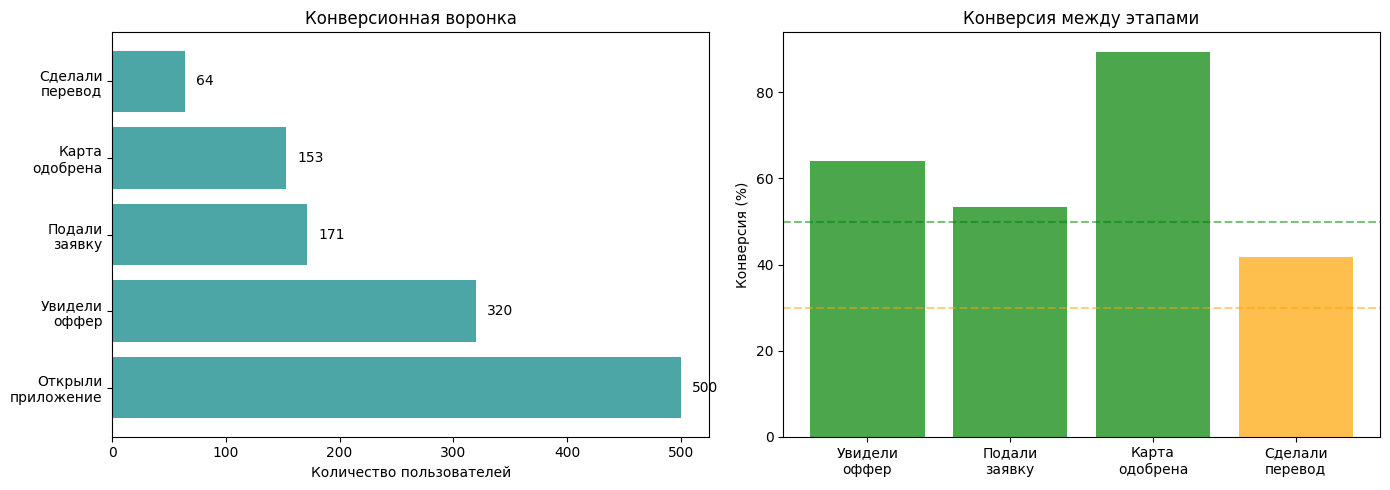

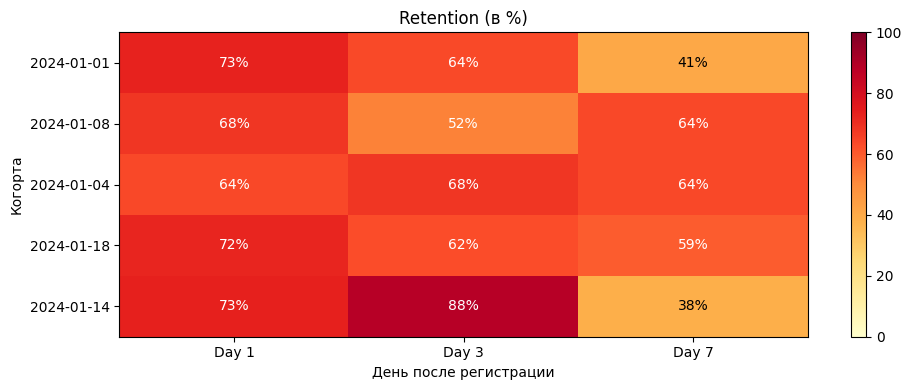

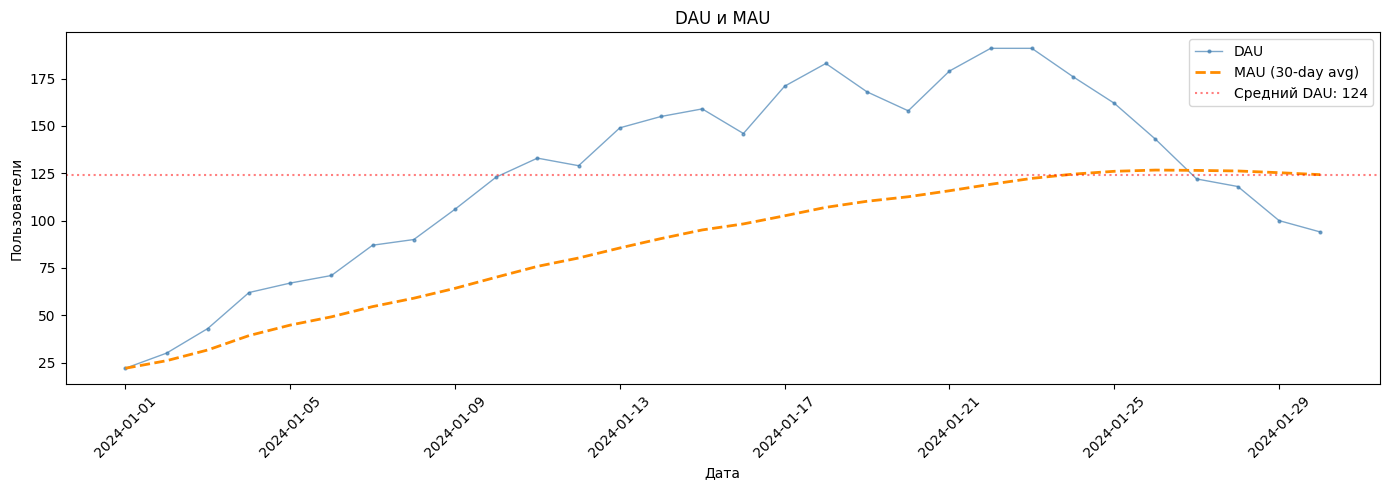

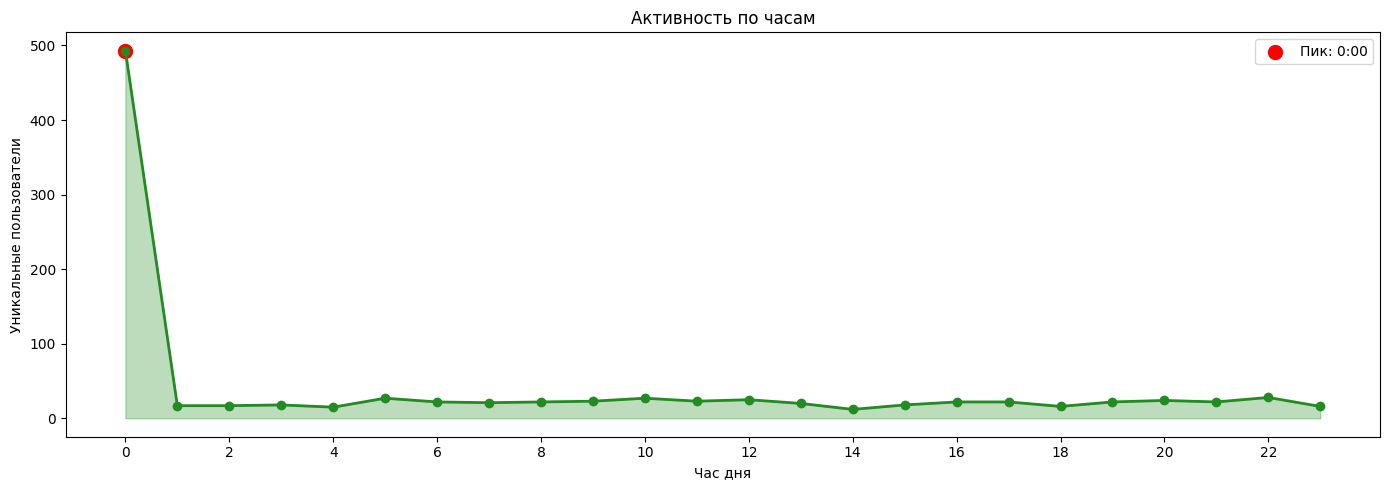

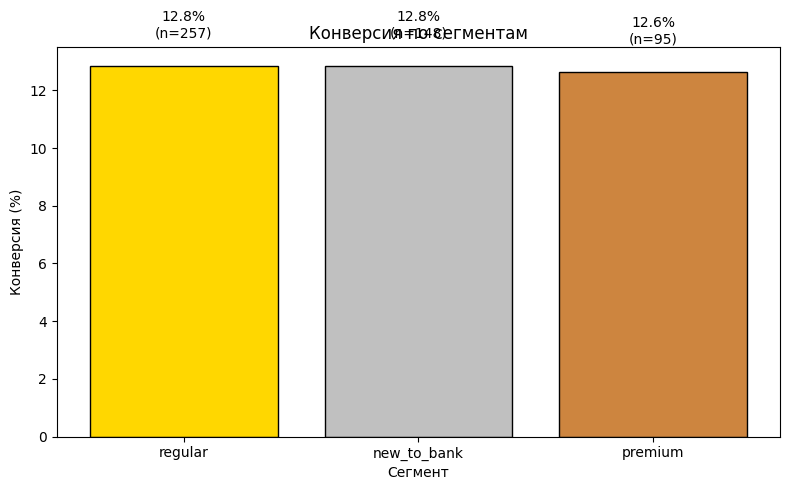

In [6]:
import matplotlib.pyplot as plt

# Преобразуем даты
df_events['event_date'] = pd.to_datetime(df_events['event_date'])

# 1. КОНВЕРСИОННАЯ ВОРОНКА

steps = ['app_open', 'view_card_offer', 'apply_card', 'card_approved', 'first_transfer']
step_names = ['Открыли\nприложение', 'Увидели\nоффер', 'Подали\nзаявку', 'Карта\nодобрена', 'Сделали\nперевод']

users_count = [df_events[df_events['event_type'] == step]['user_id'].nunique() for step in steps]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Количество пользователей
bars = ax1.barh(step_names, users_count, color='teal', alpha=0.7)
ax1.set_xlabel('Количество пользователей')
ax1.set_title('Конверсионная воронка')
for bar, val in zip(bars, users_count):
    ax1.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center')

# Конверсии
conversions = [100]
for i in range(len(users_count)-1):
    conv = (users_count[i+1] / users_count[i]) * 100 if users_count[i] > 0 else 0
    conversions.append(conv)

colors = ['green' if c > 50 else 'orange' if c > 30 else 'red' for c in conversions[1:]]
ax2.bar(step_names[1:], conversions[1:], color=colors, alpha=0.7)
ax2.set_ylabel('Конверсия (%)')
ax2.set_title('Конверсия между этапами')
ax2.axhline(y=50, color='green', linestyle='--', alpha=0.5)
ax2.axhline(y=30, color='orange', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('01_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. RETENTION HEATMAP (1, 3, 7 дни)

# Считаем retention для каждой когорты
df_events['first_date'] = df_events.groupby('user_id')['event_date'].transform('min')
df_events['cohort'] = df_events['first_date'].dt.strftime('%Y-%m-%d')
df_events['day_number'] = (df_events['event_date'] - df_events['first_date']).dt.days

cohorts = df_events['cohort'].unique()[:5]
retention_data = []

for cohort in cohorts:
    cohort_users = df_events[df_events['cohort'] == cohort]['user_id'].unique()
    row = []
    for day in [1, 3, 7]:
        active_users = df_events[
            (df_events['cohort'] == cohort) &
            (df_events['day_number'] == day)
        ]['user_id'].nunique()
        retention = (active_users / len(cohort_users)) * 100 if len(cohort_users) > 0 else 0
        row.append(retention)
    retention_data.append(row)

# Рисуем heatmap
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(retention_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(3))
ax.set_xticklabels(['Day 1', 'Day 3', 'Day 7'])
ax.set_yticks(range(len(cohorts)))
ax.set_yticklabels([c[:10] for c in cohorts])
ax.set_xlabel('День после регистрации')
ax.set_ylabel('Когорта')
ax.set_title('Retention (в %)')

for i in range(len(retention_data)):
    for j in range(3):
        text = ax.text(j, i, f'{retention_data[i][j]:.0f}%',
                       ha="center", va="center",
                       color="white" if retention_data[i][j] > 50 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('02_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. DAU + MAU (скользящее среднее)

dau = df_events[df_events['event_type'] == 'app_open'].groupby('event_date')['user_id'].nunique().reset_index()
dau.columns = ['date', 'DAU']
dau['MAU_rolling'] = dau['DAU'].rolling(window=30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dau['date'], dau['DAU'], marker='o', linewidth=1, markersize=2, color='steelblue', alpha=0.7, label='DAU')
ax.plot(dau['date'], dau['MAU_rolling'], linewidth=2, color='darkorange', label='MAU (30-day avg)', linestyle='--')
ax.axhline(y=dau['DAU'].mean(), color='red', linestyle=':', alpha=0.5, label=f'Средний DAU: {dau["DAU"].mean():.0f}')
ax.set_xlabel('Дата')
ax.set_ylabel('Пользователи')
ax.set_title('DAU и MAU')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('03_dau_mau.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. АКТИВНОСТЬ ПО ЧАСАМ

hourly = df_events[df_events['event_type'] == 'app_open'].groupby('event_hour')['user_id'].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hourly.index, hourly.values, marker='o', linewidth=2, color='forestgreen')
ax.fill_between(hourly.index, hourly.values, alpha=0.3, color='forestgreen')

peak_hour = hourly.idxmax()
ax.scatter(peak_hour, hourly.max(), color='red', s=100, label=f'Пик: {peak_hour}:00')
ax.set_xlabel('Час дня')
ax.set_ylabel('Уникальные пользователи')
ax.set_title('Активность по часам')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.savefig('04_hourly_activity.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. КОНВЕРСИЯ ПО СЕГМЕНТАМ

segment_data = []
for segment in df_users['segment'].unique():
    segment_users = df_users[df_users['segment'] == segment]['user_id'].tolist()
    opened = df_events[df_events['user_id'].isin(segment_users)]['user_id'].nunique()
    transferred = df_events[(df_events['user_id'].isin(segment_users)) &
                             (df_events['event_type'] == 'first_transfer')]['user_id'].nunique()
    conv = (transferred / opened) * 100 if opened > 0 else 0
    segment_data.append({'segment': segment, 'conversion': conv, 'users': opened})

df_seg = pd.DataFrame(segment_data)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_seg['segment'], df_seg['conversion'], color=['gold', 'silver', 'peru'], edgecolor='black')
ax.set_ylabel('Конверсия (%)')
ax.set_xlabel('Сегмент')
ax.set_title('Конверсия по сегментам')
for bar, conv, users in zip(bars, df_seg['conversion'], df_seg['users']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{conv:.1f}%\n(n={users})', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('05_segment_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

В рамках проекта проведён продуктовый анализ банковского приложения на основе данных 500 пользователей и 5 024 событий за январь 2024 года. Построена конверсионная воронка, которая выявила ключевое узкое место: после одобрения карты до первого перевода доходит только 41,8% пользователей, то есть 58,2% теряются на финальном шаге. Retention на 1 день составляет в среднем 72%, на 3 день — около 60%, на 7 день — 55%, при этом лучшая когорта показала удержание 87,5% на 7 день. DAU вырос с 22 до 123 пользователей за первые 10 дней, MAU составил 500 пользователей, а Stickiness (DAU/MAU) — 14%. Конверсия в первый перевод по сегментам оказалась одинаковой для всех групп: premium — 12,6%, regular — 12,8%, new_to_bank — 12,8%, что говорит о неэффективности текущей сегментации. На основе анализа сформулирована A/B гипотеза: добавление интерактивного чек-листа «3 шага до первого перевода» после одобрения карты увеличит конверсию с 41,8% до 55%, что даст дополнительные 132 перевода на каждые 1000 одобренных карт. В проекте использованы 6 SQL-запросов (воронка, когортный Retention, DAU, MAU, конверсия по сегментам, активность), Python для визуализации (matplotlib), а также продуктовые метрики для формулировки выводов и гипотезы.